In [2]:
import pandas as pd
import numpy as np
import json
import os
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.stats import pearsonr


### Generate Alignment Table

In [3]:
baselines = ["vanilla", "cot", "socratic", "subq"]
datasets = ["massmaps", "supernova", "politeness", "emotion", "cholec", "cardiac", "sepsis"]
models = ["gpt-5.2-pro-2025-12-11", "gpt-5-mini-2025-08-07", "claude-opus-4-5-20251101", "claude-haiku-4-5-20251001", "gemini-2.5-pro", "gemini-2.5-flash"]

# Map for pretty LaTeX-style formatting of baselines
baseline_names = {
    "vanilla": "\\textbf{Vanilla}",
    "cot": "\\textbf{Chain-of-Thought}",
    "socratic": "\\textbf{Socratic Prompting}",
    "subq": "\\textbf{SubQ Decomposition}"
}

# Collect scores
alignment_dict = defaultdict(list)
alignment_avgs = defaultdict(list)

for model in models:
    for baseline in baselines:
        for dataset in datasets:
            path = os.path.join(baseline, f"{dataset}_{model}.json")
            path = os.path.join("../results", path)
            if not os.path.exists(path):
                print(f"File not found: {path}")
                continue
            with open(path, 'r') as f:
                try:
                    data = json.load(f)
                    scores = [entry["final_alignment_score"] for entry in data if "final_alignment_score" in entry and entry["final_alignment_score"] is not None]
                    if scores:
                        alignment_dict[(baseline, dataset, model)] = scores
                        avg = sum(scores) / len(scores)
                        alignment_avgs[(baseline, dataset, model)] = avg
                    #print length of scores
                    # if(len(scores) < 100): print(f"Warning: Less than 100 scores for {baseline} on {dataset}: {len(scores)}")

                except Exception as e:
                    print(scores)
                    print(f"Error processing {path}: {e}")

    # Generate LaTeX rows
    print("-----------{}------------".format(model))
    for baseline in baselines:
        row = [baseline_names[baseline]]
        for dataset in datasets:
            avg_score = alignment_avgs.get((baseline, dataset, model), "")
            if isinstance(avg_score, float):
                row.append(f"{avg_score:.3f}")
            else:
                row.append("")  # Leave blank if not available
                # print(f"Warning: No score found for {baseline} on {dataset}")
        print(" & ".join(row) + " \\\\")

-----------gpt-5.2-pro-2025-12-11------------
\textbf{Vanilla} & 0.901 & 0.845 & 0.882 & 0.906 & 0.538 & 0.539 & 0.425 \\
\textbf{Chain-of-Thought} & 0.907 & 0.880 & 0.876 & 0.898 & 0.632 & 0.587 & 0.394 \\
\textbf{Socratic Prompting} & 0.804 & 0.714 & 0.763 & 0.726 & 0.656 & 0.488 & 0.381 \\
\textbf{SubQ Decomposition} & 0.812 & 0.727 & 0.857 & 0.774 & 0.639 & 0.489 & 0.356 \\
-----------gpt-5-mini-2025-08-07------------
\textbf{Vanilla} & 0.844 & 0.891 & 0.875 & 0.867 & 0.757 & 0.522 & 0.410 \\
\textbf{Chain-of-Thought} & 0.759 & 0.876 & 0.767 & 0.830 & 0.609 & 0.507 & 0.395 \\
\textbf{Socratic Prompting} & 0.729 & 0.781 & 0.641 & 0.690 & 0.506 & 0.444 & 0.399 \\
\textbf{SubQ Decomposition} & 0.720 & 0.838 & 0.809 & 0.846 & 0.528 & 0.443 & 0.419 \\
-----------claude-opus-4-5-20251101------------
\textbf{Vanilla} & 0.774 & 0.781 & 0.827 & 0.916 & 0.753 & 0.675 & 0.376 \\
\textbf{Chain-of-Thought} & 0.784 & 0.752 & 0.854 & 0.912 & 0.772 & 0.627 & 0.396 \\
\textbf{Socratic Prompting} & 

In [4]:
import os, json
from collections import defaultdict
import numpy as np

baselines = ["vanilla", "cot", "socratic", "subq"]
datasets = ["massmaps", "supernova", "politeness", "emotion", "cholec", "cardiac", "sepsis"]
models = ["gpt-5.2-pro-2025-12-11", "gpt-5-mini-2025-08-07", "claude-opus-4-5-20251101",
          "claude-haiku-4-5-20251001", "gemini-2.5-pro", "gemini-2.5-flash"]

baseline_names = {
    "vanilla": "\\textbf{Vanilla}",
    "cot": "\\textbf{Chain-of-Thought}",
    "socratic": "\\textbf{Socratic Prompting}",
    "subq": "\\textbf{SubQ Decomposition}"
}

model_names = {
    "gpt-5.2-pro-2025-12-11": "GPT-5.2-Pro",
    "gpt-5-mini-2025-08-07": "GPT-5-Mini",
    "claude-opus-4-5-20251101": "Claude-Opus-4.5",
    "claude-haiku-4-5-20251001": "Claude-Haiku-4.5",
    "gemini-2.5-pro": "Gemini-2.5-Pro",
    "gemini-2.5-flash": "Gemini-2.5-Flash",
}

# ------------ load avgs ------------
alignment_avgs = {}  # (baseline, dataset, model) -> float

for model in models:
    for baseline in baselines:
        for dataset in datasets:
            path = os.path.join("../results", baseline, f"{dataset}_{model}.json")
            if not os.path.exists(path):
                alignment_avgs[(baseline, dataset, model)] = None
                continue
            with open(path, "r") as f:
                try:
                    data = json.load(f)
                    scores = [
                        entry["final_alignment_score"]
                        for entry in data
                        if entry.get("final_alignment_score") is not None
                    ]
                    alignment_avgs[(baseline, dataset, model)] = (sum(scores) / len(scores)) if scores else None
                except Exception as e:
                    print(f"Error processing {path}: {e}")
                    alignment_avgs[(baseline, dataset, model)] = None

# ------------ compute highlights (ties by displayed precision) ------------
# per-model best: within each (model, dataset), best over baselines
rounded = {}  # (baseline, dataset, model) -> rounded float or None
for k, v in alignment_avgs.items():
    rounded[k] = None if v is None else float(f"{v:.3f}")

per_model_best = set()
for model in models:
    for dataset in datasets:
        vals = [(baseline, rounded[(baseline, dataset, model)]) for baseline in baselines]
        numeric = [v for _, v in vals if v is not None]
        if not numeric:
            continue
        m = max(numeric)
        for baseline, v in vals:
            if v is not None and v == m:
                per_model_best.add((baseline, dataset, model))

# global best: for each dataset, best over all (model, baseline)
global_best = set()
for dataset in datasets:
    vals = [((baseline, dataset, model), rounded[(baseline, dataset, model)])
            for model in models for baseline in baselines]
    numeric = [v for _, v in vals if v is not None]
    if not numeric:
        continue
    m = max(numeric)
    for key, v in vals:
        if v is not None and v == m:
            b, d, mo = key
            global_best.add((b, d, mo))

def fmt_cell(baseline, dataset, model):
    v = rounded.get((baseline, dataset, model), None)
    if v is None:
        return "NA"
    s = f"{v:.3f}"
    if (baseline, dataset, model) in global_best:
        return f"\\bestoverall{{{s}}}"
    if (baseline, dataset, model) in per_model_best:
        return f"\\best{{{s}}}"
    return s

# ------------ print full LaTeX tabular ------------
print("\\begin{tabular}{lccccccc}")
print("\\toprule")
print("\\multirow{2}{*}{} & \\multicolumn{2}{c}{\\textit{Cosmology}} & "
      "\\multicolumn{2}{c}{\\textit{Psychology}} & \\multicolumn{3}{c}{\\textit{Medicine}} \\\\")
print("\\textbf{Baseline} \\hspace{0.2cm} & \\textbf{Mass Maps}  & \\textbf{Supernova} \\hspace{0.1cm}    &  "
      "\\hspace{0.1cm} \\textbf{Politeness} & \\textbf{Emotion} \\hspace{0.1cm} & \\hspace{0.1cm} "
      "\\textbf{Cholecystectomy}     &  \\textbf{Cardiac} & \\textbf{Sepsis} \\\\")
print("\\midrule")

for model in models:
    pretty = model_names.get(model, model)
    print(f"\\multicolumn{{8}}{{l}}{{\\textit{{{pretty}}}}} \\\\")
    print("\\midrule")
    for baseline in baselines:
        row = [baseline_names[baseline]]
        for dataset in datasets:
            row.append(fmt_cell(baseline, dataset, model))
        print(" & ".join(row) + " \\\\")
    print("\\midrule")

print("\\bottomrule")
print("\\end{tabular}")


\begin{tabular}{lccccccc}
\toprule
\multirow{2}{*}{} & \multicolumn{2}{c}{\textit{Cosmology}} & \multicolumn{2}{c}{\textit{Psychology}} & \multicolumn{3}{c}{\textit{Medicine}} \\
\textbf{Baseline} \hspace{0.2cm} & \textbf{Mass Maps}  & \textbf{Supernova} \hspace{0.1cm}    &  \hspace{0.1cm} \textbf{Politeness} & \textbf{Emotion} \hspace{0.1cm} & \hspace{0.1cm} \textbf{Cholecystectomy}     &  \textbf{Cardiac} & \textbf{Sepsis} \\
\midrule
\multicolumn{8}{l}{\textit{GPT-5.2-Pro}} \\
\midrule
\textbf{Vanilla} & 0.901 & 0.845 & \best{0.882} & \best{0.906} & 0.538 & 0.539 & \best{0.425} \\
\textbf{Chain-of-Thought} & \bestoverall{0.907} & \best{0.880} & 0.876 & 0.898 & 0.632 & \best{0.587} & 0.394 \\
\textbf{Socratic Prompting} & 0.804 & 0.714 & 0.763 & 0.726 & \best{0.656} & 0.488 & 0.381 \\
\textbf{SubQ Decomposition} & 0.812 & 0.727 & 0.857 & 0.774 & 0.639 & 0.489 & 0.356 \\
\midrule
\multicolumn{8}{l}{\textit{GPT-5-Mini}} \\
\midrule
\textbf{Vanilla} & \best{0.844} & \bestoverall{0.891} 

### Generate Accuracy Table

In [5]:
baselines = ["vanilla", "cot", "socratic", "subq"]
datasets = ["massmaps", "supernova", "politeness", "emotion", "cholec", "cardiac", "sepsis"]
models = ["gpt-5.2-pro-2025-12-11", "gpt-5-mini-2025-08-07", "claude-opus-4-5-20251101", "claude-haiku-4-5-20251001", "gemini-2.5-pro", "gemini-2.5-flash"]

# Map for pretty LaTeX-style formatting of baselines
baseline_names = {
    "vanilla": "\\textbf{Vanilla}",
    "cot": "\\textbf{Chain-of-Thought}",
    "socratic": "\\textbf{Socratic Prompting}",
    "subq": "\\textbf{SubQ Decomposition}"
}

mse_domians = ["massmaps", "politeness", "cholec"]


# Collect scores
accuracy_dict = defaultdict(list)
accuracy_avgs = defaultdict(list)

for model in models:
    for baseline in baselines:
        for dataset in datasets:
            path = os.path.join(baseline, f"{dataset}_{model}.json")
            path = os.path.join("../results", path)
            if not os.path.exists(path):
                print(f"File not found: {path}")
                continue
            with open(path, 'r') as f:
                try:
                    accuracy = []
                    data = json.load(f)
                    if "final_aligned_score" in data[0]:
                        for entry in data:
                            entry["final_alignment_score"] = entry["final_aligned_score"]
                            del entry["final_aligned_score"]
                    if "accuracy" in data[0]:
                        accuracy = [entry["accuracy"] for entry in data if entry["accuracy"] is not None and entry["final_alignment_score"] is not None]   
                    elif "mse" in data[0]:
                        accuracy = [entry["mse"] for entry in data if entry["mse"] is not None and entry["final_alignment_score"] is not None]   
                    elif "mse_loss" in data[0]:
                        accuracy = [(entry["mse_loss"]["Omega_m"] + entry["mse_loss"]["sigma_8"])/2 for entry in data if entry["mse_loss"] is not None and entry["final_alignment_score"] is not None]
                    elif "safe_iou" in data[0]:
                        accuracy = [(entry["safe_iou"] + entry["unsafe_iou"])/2 for entry in data if entry["safe_iou"] is not None and entry["final_alignment_score"] is not None]
                    else:
                        print(f"Neither accuracy nor mse found in {path}")           
                    if accuracy:
                        accuracy_dict[(baseline, dataset, model)] = accuracy
                        avg = sum(accuracy) / len(accuracy)
                        accuracy_avgs[(baseline, dataset, model)] = avg
                        
                    # if(len(accuracy) < 100): print(f"Warning: Less than 100 scores for {baseline} on {dataset}: {len(accuracy)}")
                except Exception as e:
                    print(f"Error processing {path}: {e.with_traceback()}")

    print("-----------{}------------".format(model))
    for baseline in baselines:
        row = [baseline_names[baseline]]
        for dataset in datasets:
            avg_score = accuracy_avgs.get((baseline, dataset, model), "")
            if isinstance(avg_score, float):
                row.append(f"{avg_score:.3f}{'$^*$' if dataset in mse_domians else ''}")
            else:
                row.append("")  # Leave blank if not available
                # print(f"Warning: No score found for {baseline} on {dataset}")
        print(" & ".join(row) + " \\\\")


-----------gpt-5.2-pro-2025-12-11------------
\textbf{Vanilla} & 0.060$^*$ & 0.236 & 0.801$^*$ & 0.320 & 0.014$^*$ & 0.612 & 0.627 \\
\textbf{Chain-of-Thought} & 0.058$^*$ & 0.218 & 0.868$^*$ & 0.340 & 0.162$^*$ & 0.623 & 0.618 \\
\textbf{Socratic Prompting} & 0.062$^*$ & 0.218 & 0.841$^*$ & 0.300 & 0.098$^*$ & 0.623 & 0.637 \\
\textbf{SubQ Decomposition} & 0.061$^*$ & 0.227 & 0.871$^*$ & 0.340 & 0.146$^*$ & 0.623 & 0.627 \\
-----------gpt-5-mini-2025-08-07------------
\textbf{Vanilla} & 0.048$^*$ & 0.191 & 1.004$^*$ & 0.410 & 0.149$^*$ & 0.585 & 0.624 \\
\textbf{Chain-of-Thought} & 0.046$^*$ & 0.164 & 1.048$^*$ & 0.350 & 0.067$^*$ & 0.577 & 0.676 \\
\textbf{Socratic Prompting} & 0.047$^*$ & 0.200 & 1.018$^*$ & 0.310 & 0.018$^*$ & 0.585 & 0.627 \\
\textbf{SubQ Decomposition} & 0.050$^*$ & 0.164 & 1.024$^*$ & 0.340 & 0.011$^*$ & 0.577 & 0.608 \\
-----------claude-opus-4-5-20251101------------
\textbf{Vanilla} & 0.035$^*$ & 0.082 & 0.701$^*$ & 0.300 & 0.273$^*$ & 0.454 & 0.618 \\
\textbf

In [6]:
#go through each json and calculate the number of relevant claims vs. the total claims
possible_claim_keys = ["claims", "all_claims"]
total_claims = 0
relevant_claims = 0
for model in models:
    for baseline in baselines:
        for dataset in datasets:
            path = os.path.join(baseline, f"{dataset}_{model}.json")
            path = os.path.join("../results", path)
            try:
                with open(path, 'r') as f:
                    data = json.load(f)
                    for example in data:
                        example_claims = 0
                        example_relevant_claims = 0
                        if "claims" in example:
                            example_claims = len(example["claims"])
                        elif "all_claims" in example:
                            example_claims = len(example["all_claims"])
                        if "relevant_claims" in example:
                            example_relevant_claims = len(example["relevant_claims"])
                        total_claims += example_claims
                        relevant_claims += example_relevant_claims       
                        if(relevant_claims/total_claims < 0.7):
                            print(example["claims"])
                            print(example["relevant_claims"])
                            print("--------------------------------")
            except:
                print(f"Error processing {path}")

print(f"Total claims: {total_claims}")
print(f"Relevant claims: {relevant_claims}")
print(f"Relevance ratio: {relevant_claims/total_claims}")


Error processing ../results/subq/politeness_gemini-2.5-pro.json
Total claims: 237669
Relevant claims: 181631
Relevance ratio: 0.7642183036071175


### Criteria Coverage Analysis

In [27]:
from collections import Counter
from math import log2

def shannon_entropy(data):
    total = len(data)
    counts = Counter(data)
    k = len(counts)  # number of unique elements
    if k <= 1:
        return 0.0  # No uncertainty if only one unique value

    entropy = -sum((freq / total) * log2(freq / total) for freq in counts.values())
    max_entropy = log2(k)
    return entropy / max_entropy

def make_entropy_plot(models):

    baselines = ["vanilla", "cot", "socratic", "subq"]
    datasets = ["massmaps", "supernova", "politeness", "emotion", "cholec", "cardiac", "sepsis"]
    models = models

    dataset_names = {
        "massmaps": "Mass Maps",
        "supernova": "Supernova",
        "politeness": "Politeness",
        "emotion": "Emotion",
        "cholec": "Cholecystectomy",
        "cardiac": "Cardiac",
        "sepsis": "Sepsis"
    }

    baseline_names = {
        "vanilla": "Vanilla",
        "cot": "Chain-of-Thought",
        "socratic": "Socratic Prompting",
        "subq": "SubQ Decomposition"
    }

    entropies = defaultdict(list)

    for baseline in baselines:
        for model in models: 
            for dataset in datasets:
                categories_all = []
                path = os.path.join(baseline, f"{dataset}_{model}.json")
                path = os.path.join("../results", path)
                if not os.path.exists(path):
                    print(f"File not found: {path}")
                    continue
                with open(path, 'r') as f:
                    try:
                        categories = []
                        data = json.load(f)
                        for entry in data:
                            category_alignment_scores = entry["category_alignment_scores"]
                            non_zero_cats = []
                            for cat in category_alignment_scores:
                                if category_alignment_scores[cat] == 1:
                                    non_zero_cats.append(cat)
                            categories.append(non_zero_cats)
                        # if "alignment_categories" in data[0]:
                        #     categories = [entry["alignment_categories"] for entry in data if entry["alignment_categories"] is not None] 
                        # elif "alignment_category" in data[0]:
                        #     categories = [entry["alignment_category"] for entry in data if entry["alignment_category"] is not None]
                        # elif "aligned_category_ids" in data[0]:
                        #     categories = [entry["aligned_category_ids"] for entry in data if entry["aligned_category_ids"] is not None]
                        # elif "alignment_category_ids" in data[0]:
                        #     categories = [entry["alignment_category_ids"] for entry in data if entry["alignment_category_ids"] is not None]
                        # else:
                        #     raise ValueError(f"alignment_categories not found in {path}") 
                        for category_list in categories:
                            for category_item in category_list:
                                if category_item is not None:
                                    categories_all.append(category_item)
                    except Exception as e:
                        print(f"Error processing {path}: {e}")           

                names, counts = np.unique(categories_all, return_counts=True)
                ent = shannon_entropy(categories_all)
                entropies[(baseline, dataset)] = ent

    entropy_data = entropies
    # Convert to DataFrame
    rows = [(baseline_names[baseline], dataset_names[dataset], value) for (baseline, dataset), value in entropy_data.items()]
    df = pd.DataFrame(rows, columns=["Baseline", "Dataset", "Entropy"])

    mpl.rcParams.update({
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
        'axes.labelweight': 'normal',
        'axes.titlesize': 12,
        'axes.labelsize': 12,
        'xtick.labelsize': 12,
        'ytick.labelsize': 10,
        'legend.fontsize': 10
    })

    # Avoid Seaborn overriding the font
    sns.set_style("whitegrid", rc={
        'font.family': 'serif',
        'axes.labelweight': 'normal',
        'axes.edgecolor': '0.8'
    })

    # Plot setup
    plt.figure(figsize=(10, 2.75))  # Adjust size to fit Overleaf width
    palette = sns.color_palette("deep")

    # Create horizontal barplot
    sns.barplot(
        data=df,
        y="Entropy", x="Dataset", hue="Baseline",
        dodge=True,
        palette=palette
    )

    # Formatting
    plt.title("Criteria Entropy across Datasets & Strategies", fontsize=14)
    plt.xlabel("", labelpad=0)
    plt.ylabel("Shannon Entropy")
    plt.legend(
        title="Prompting Strategy",
        loc="lower right",
        bbox_to_anchor=(1, 0),
        frameon=True,
        facecolor='white',
        edgecolor='black'
    )
    plt.tight_layout()

    # Save to file
    plt.savefig("entropy_histogram.pdf")  # Or .png if you prefer
    plt.show()

/tmp/ipykernel_4094259/3644924051.py:109: UserWarning: The palette list has more values (10) than needed (4), which may not be intended.
  sns.barplot(


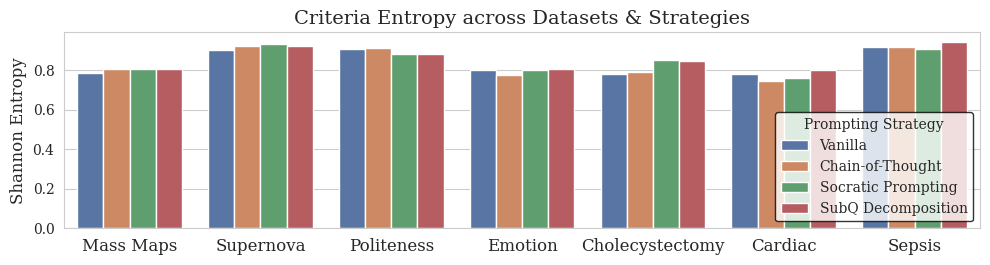

In [30]:
make_entropy_plot(["gpt-5-mini-2025-08-07"])

### Correlation Heatmap

/tmp/ipykernel_4094259/740183765.py:72: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = heatmap_data.applymap(lambda x: f"{x:.2f}" if pd.notnull(x) else "")


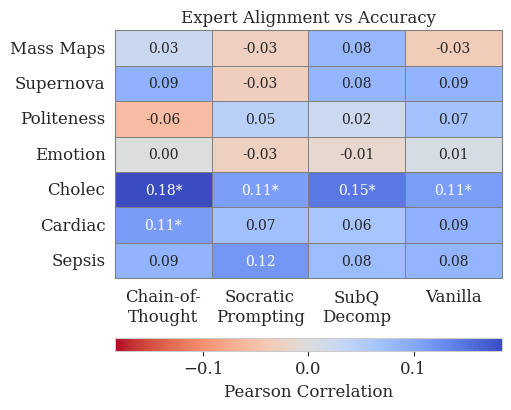

In [13]:
from scipy.stats import pearsonr, combine_pvalues  # add combine_pvalues

models = ["gpt-5.2-pro-2025-12-11", "gpt-5-mini-2025-08-07", "claude-opus-4-5-20251101", "claude-haiku-4-5-20251001", "gemini-2.5-pro", "gemini-2.5-flash"]

dataset_names = {
    "massmaps": "Mass Maps",
    "supernova": "Supernova",
    "politeness": "Politeness",
    "emotion": "Emotion",
    "cholec": "Cholec",
    "cardiac": "Cardiac",
    "sepsis": "Sepsis"
}
baseline_names = {
    "vanilla": "Vanilla",
    "cot": "Chain-of-\nThought",
    "socratic": "Socratic\nPrompting",
    "subq": "SubQ\nDecomp"
}

all_model_data = []
for model in models:
    data = defaultdict(list)
    for key in alignment_dict:
        align = alignment_dict.get(key)
        if key[2] != model:
            continue
        acc = accuracy_dict.get(key)
        if align and acc and len(align) == len(acc):
            corr, p = pearsonr(align, acc)  # keep p-value
        else:
            print(f"Warning: Mismatched lengths for {key}: {len(align)} vs {len(acc)}")
            continue

        baseline, dataset, _ = key
        data[(baseline, dataset)] = (corr, p)  # store both

    all_model_data.append(data)

data = []
for key in all_model_data[0]:
    # Check if the key exists in all models
    for i in range(1, len(models)):
        if key not in all_model_data[i]:
            print(f"Warning: Key {key} not found in model {models[i]}")
            break

    corrs = [all_model_data[i][key][0] for i in range(len(models)) if key in all_model_data[i]]
    ps    = [all_model_data[i][key][1] for i in range(len(models)) if key in all_model_data[i]]

    avg_corr = np.mean(corrs)
    combined_p = combine_pvalues(ps, method="fisher")[1] if len(ps) else np.nan  # aggregate significance

    data.append((baseline_names[key[0]], key[1], avg_corr, combined_p))

# Step 2: Convert to DataFrame
df_corr = pd.DataFrame(data, columns=['Baseline', 'Dataset', 'Correlation', 'PValue'])

# Step 3: Pivot for heatmap
dataset_order = list(dataset_names.keys())
dataset_order_readable = [dataset_names[d] for d in dataset_order]

df_corr['Dataset'] = df_corr['Dataset'].map(dataset_names)

heatmap_data = df_corr.pivot(index='Dataset', columns='Baseline', values='Correlation')
pval_data    = df_corr.pivot(index='Dataset', columns='Baseline', values='PValue')

heatmap_data = heatmap_data.reindex(index=dataset_order_readable)
pval_data    = pval_data.reindex(index=dataset_order_readable)

# Build annotation strings with * for p < 0.05
annot = heatmap_data.applymap(lambda x: f"{x:.2f}" if pd.notnull(x) else "")
sig_mask = pval_data < 0.05
annot = annot.where(~sig_mask, annot + "*")

# Step 4: Plot heatmap
fig, ax = plt.subplots(figsize=(5, 3.5), constrained_layout=True)

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif']

sns_heatmap = sns.heatmap(
    heatmap_data,
    annot=annot,          # <-- use string annotations with *
    fmt="",               # <-- tell seaborn not to re-format strings
    center=0,
    linewidths=0.5,
    linecolor='gray',
    cmap="coolwarm_r",
    cbar=False,
    ax=ax
)

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.6)

vmax = heatmap_data.max().max()
norm = plt.Normalize(vmin=-vmax, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap="coolwarm_r", norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label("Pearson Correlation")

ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_title("Expert Alignment vs Accuracy")
ax.set_xlabel("")
ax.set_ylabel("")

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('gray')

plt.savefig("correlation_heatmap.pdf", bbox_inches='tight')
plt.show()


In [31]:
#iterate through politeness jsons for all models
models = ["gpt-5.2-pro-2025-12-11", "gpt-5-mini-2025-08-07", "claude-opus-4-5-20251101", "claude-haiku-4-5-20251001", "gemini-2.5-pro", "gemini-2.5-flash"]
baselines = ["vanilla", "cot", "socratic", "subq"]
datasets = ["emotion", "politeness"]
for dataset in datasets:
    for baseline in baselines:
        for model in models:
            path = os.path.join(baseline, f"{dataset}_{model}.json")
            path = os.path.join("../results", path)
            try:
                with open(path, 'r') as f:
                    data = json.load(f)
                    for example in data:
                        #rename final_aligned_score to final_alignment_score
                        if "final_aligned_score" in example:
                            example["final_alignment_score"] = example["final_aligned_score"]
                            del example["final_aligned_score"]
            except:
                print(f"Error processing {path}")
                continue
                #save fixed json
            with open(path, 'w') as f:
                json.dump(data, f, indent=4)
                    